## 프로젝트 개요 및 회고
### 1. 프로젝트 개요
- 본 프로젝트의 목적은 Hugging Face의 Transformer 모델을 활용하여 한국어 감성 분석 모델을 구축하고,
-  입력 데이터 전처리 방식에 따른 학습 효율과 모델 성능의 차이를 분석하는 것이다.
-  이를 위해 한국어 영화 리뷰 데이터셋인 NSMC(Naver Sentiment Movie Corpus)를 활용하여 klue/bert-base 모델을 fine-tuning하였다.

#### 프로젝트는 다음과 같은 단계로 진행되었다.

- 먼저 Hugging Face의 datasets 라이브러리를 사용하여 NSMC 데이터를 불러오고,
- 학습(train), 검증(validation), 테스트(test) 데이터로 구성된 데이터셋 구조를 확인하였다.
- 이후 klue/bert-base tokenizer를 이용해 리뷰 텍스트를 모델 입력 형태인 input_ids, attention_mask, token_type_ids로 변환하였다.

- 다음 단계에서는 static padding 방식을 적용하여 모든 문장을 동일한 길이로 맞춘 후 모델을 학습하였다.
- Trainer API를 이용해 모델을 fine-tuning 하였으며, 학습 과정에서 validation accuracy와 F1 score를 평가 지표로 사용하였다.

- 그 결과 validation accuracy는 약 0.906, test accuracy는 약 0.904 수준으로 나타나 목표로 설정한 90% 이상의 성능을 달성하였다.
-  이를 통해 klue/bert-base 모델이 한국어 감성 분석 작업에서 효과적으로 작동함을 확인하였다.

- 또한 학습 과정에서 loss curve와 validation metric 변화를 분석하여 모델의 학습 상태를 확인하였다.

#### 2. 실험 결과

- Static Padding 방식으로 학습한 결과는 다음과 같다.
- Validation Accuracy: 0.906
- Validation F1 Score: 0.906
- Test Accuracy: 0.904

- 학습 곡선을 분석한 결과, training loss는 epoch이 증가할수록 지속적으로 감소하였으며 validation loss는 점차 증가하는 경향을 보였다.
-  이는 모델이 학습 데이터에 점차 적합해지면서 약한 overfitting 경향이 나타났음을 의미한다.
-   반면 validation accuracy와 F1 score는 epoch이 진행될수록 증가하다가 후반부에서 수렴하는 모습을 보였다.
  
### 3. 학습목표(루브릭 결과) 달성 여부
- 모델 학습에 Bucketing을 성공적으로 적용하고, 그 결과를 비교분석하였다.
- Bucketing task을 수행하여 fine-tuning 시 연산 속도와 모델 성능 간의 trade-off 관계가 발생하는지 여부를 확인하고, 분석한 결과를 제시하였다.
 - Baseline:
 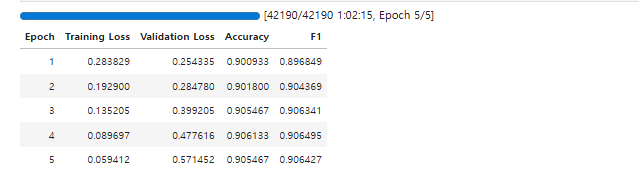
- Bucketing:
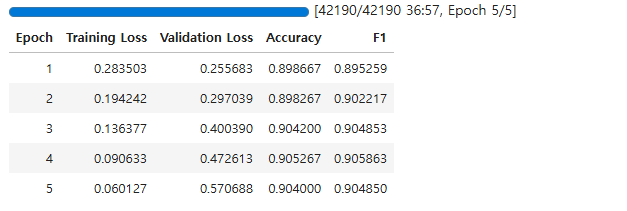
- 성능비교
 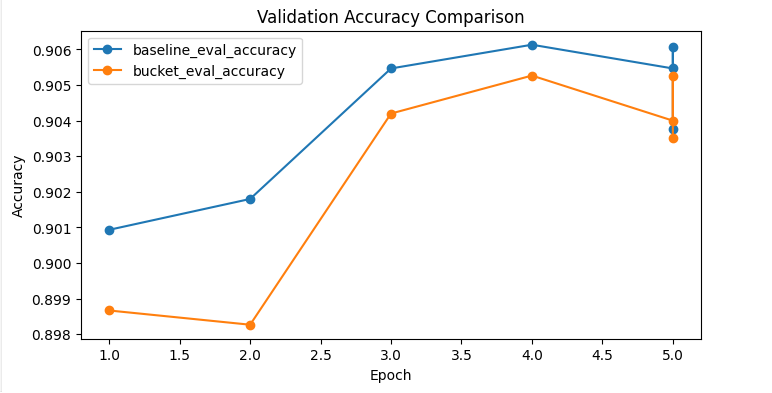
- 연산속도는 bucketing하지 않은 베이스라인 모델이 62분 15초, Bucketing 모델이 36분 57초로 25분 18초(약 40.7%) 단축
- 반면 성능은 약 0.1 % 떨어짐을 확인함
  
- Preprocessing을 개선하고, fine-tuning을 통해 모델의 성능을 개선시켰다.
- Validation accuracy를 90% 이상으로 개선
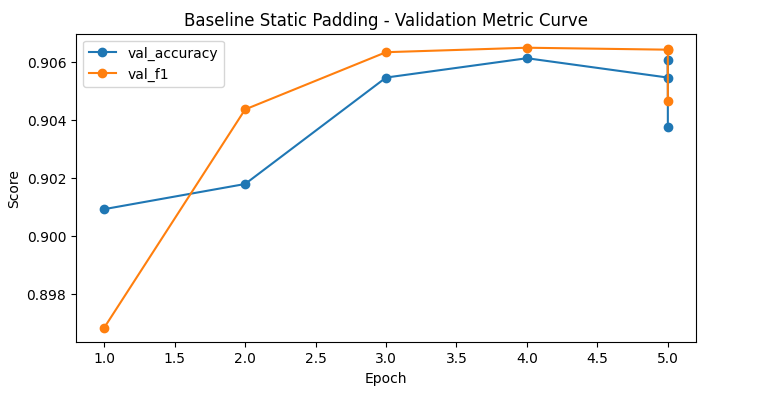
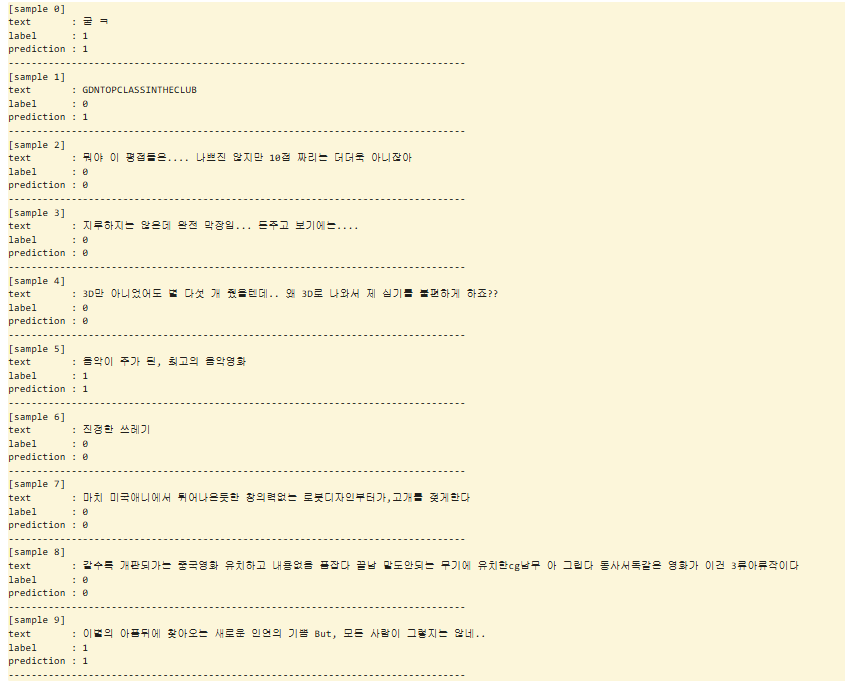
- 모델과 데이터를 정상적으로 불러오고, 작동하는 것을 확인하였다.
- klue/bert-base를 NSMC 데이터셋으로 fine-tuning 하여, 모델이 정상적으로 작동하는 것을 확인하였다.
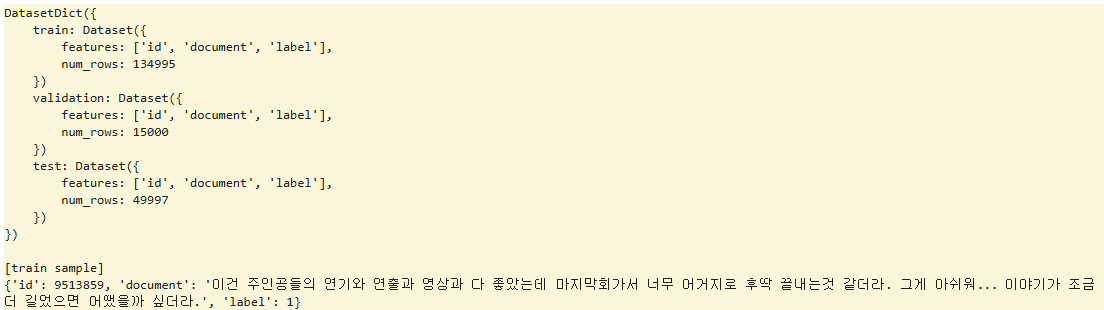
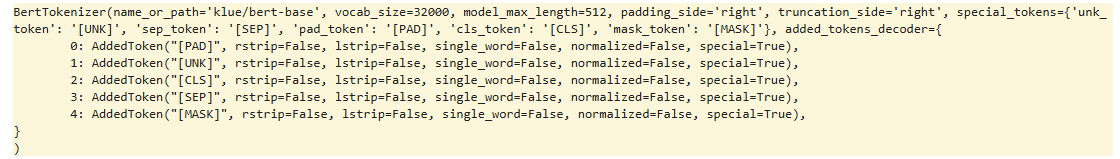

### 3. 회고
- 이번 프로젝트를 통해 Hugging Face의 Transformer 모델을 활용한 자연어 처리 파이프라인을 실제로 구성해 볼 수 있었다.
- 특히 datasets 라이브러리와 Trainer API를 활용하여 데이터 전처리, 모델 학습, 평가 과정을 확인하였다.

- 또한 tokenizer를 통해 텍스트 데이터를 모델 입력 형태로 변환하는 과정과, padding 방식이 학습 효율에 영향을 줄 수 있다는 점을 이해할 수 있었다.
- Static padding 방식과 Bucketing 방식을 비교함으로써 효율성과 성능의 Trade off 관계를 확인하였다.


### Project Process
- STEP 0: 캐시 삭제 / 라이브러리 / 시드 / 환경 확인
- STEP 1: NSMC 데이터 다운로드 + train/val/test 구성
- STEP 2: klue/bert-base tokenizer / model 준비
- STEP 3: 전처리 함수 / metric / 공통 유틸 함수 준비
- STEP 4: 기본 학습(static padding) + early stopping
- STEP 5: 테스트 평가 + 예측 샘플 + 러닝커브
- STEP 6: bucketing(dynamic padding + group_by_length) 학습
- STEP 7: 두 실험 결과 비교

### STEP 0. 라이브러리 / 시드 / 환경 확인

In [1]:
import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("memory cleared")

memory cleared


In [2]:
# ============================================================
# [STEP 0 - CELL 1] 라이브러리 import / 버전 / 시드 고정
# - 재현성을 위해 seed 고정
# - GPU 사용 가능 여부 확인
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import datasets
import transformers
import evaluate

from datasets import load_dataset, DatasetDict
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
    set_seed,
)

print("datasets version     :", datasets.__version__)
print("transformers version :", transformers.__version__)
print("evaluate version     :", evaluate.__version__)
print("torch version        :", torch.__version__)
print("cuda available       :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name          :", torch.cuda.get_device_name(0))


# -----------------------------
# 시드 고정 함수
# -----------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

seed_everything(42)

datasets version     : 4.7.0
transformers version : 5.2.0
evaluate version     : 0.4.6
torch version        : 2.8.0+cu126
cuda available       : True
device name          : NVIDIA GeForce RTX 3090


### STEP 1. NSMC 다운로드 및 train / val / test 구성

In [5]:
# ============================================================
# [STEP 1 - CELL 1] NSMC 원본 파일 다운로드
# - Hugging Face Hub의 nsmc 스크립트 로딩 대신
# - GitHub 원본 TSV 파일을 직접 내려받음
# ============================================================

import os
import urllib.request

os.makedirs("data/nsmc", exist_ok=True)

train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url  = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

train_path = "data/nsmc/ratings_train.txt"
test_path  = "data/nsmc/ratings_test.txt"

urllib.request.urlretrieve(train_url, train_path)
urllib.request.urlretrieve(test_url, test_path)

print("다운로드 완료")
print(train_path)
print(test_path)

다운로드 완료
data/nsmc/ratings_train.txt
data/nsmc/ratings_test.txt


In [6]:
# ============================================================
# [STEP 1 - CELL 2] NSMC TSV 파일 읽기
# - ratings_train.txt / ratings_test.txt는 탭 구분자 파일
# ============================================================

import pandas as pd

train_df = pd.read_csv(train_path, sep="\t")
test_df = pd.read_csv(test_path, sep="\t")

print("train_df shape:", train_df.shape)
print("test_df shape :", test_df.shape)

print("\n[train head]")
print(train_df.head())

train_df shape: (150000, 3)
test_df shape : (50000, 3)

[train head]
         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1


In [7]:
# ============================================================
# [STEP 1 - CELL 3] 결측치 제거 및 타입 정리
# ============================================================

def clean_nsmc_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    cleaned_df = df.copy()
    cleaned_df["document"] = cleaned_df["document"].fillna("").astype(str)
    cleaned_df = cleaned_df[cleaned_df["document"].str.strip() != ""].copy()
    cleaned_df["label"] = cleaned_df["label"].astype(int)
    cleaned_df = cleaned_df.reset_index(drop=True)
    return cleaned_df

train_df = clean_nsmc_dataframe(train_df)
test_df = clean_nsmc_dataframe(test_df)

print("cleaned train_df shape:", train_df.shape)
print("cleaned test_df shape :", test_df.shape)
print("\n[train label distribution]")
print(train_df["label"].value_counts().sort_index())

cleaned train_df shape: (149995, 3)
cleaned test_df shape : (49997, 3)

[train label distribution]
label
0    75170
1    74825
Name: count, dtype: int64


In [8]:
# ============================================================
# [STEP 1 - CELL 4] train / validation 분리
# - test는 그대로 유지
# ============================================================

from sklearn.model_selection import train_test_split

train_df_split, val_df_split = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df["label"],
)

train_df_split = train_df_split.reset_index(drop=True)
val_df_split = val_df_split.reset_index(drop=True)

print("train_df_split shape:", train_df_split.shape)
print("val_df_split shape  :", val_df_split.shape)
print("test_df shape       :", test_df.shape)

train_df_split shape: (134995, 3)
val_df_split shape  : (15000, 3)
test_df shape       : (49997, 3)


In [9]:
# ============================================================
# [STEP 1 - CELL 5] Hugging Face DatasetDict 구성
# ============================================================

from datasets import Dataset, DatasetDict

nsmc_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df_split, preserve_index=False),
    "validation": Dataset.from_pandas(val_df_split, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False),
})

print(nsmc_dataset)
print("\n[train sample]")
print(nsmc_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 134995
    })
    validation: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 49997
    })
})

[train sample]
{'id': 9513859, 'document': '이건 주인공들의 연기와 연출과 영상과 다 좋았는데 마지막회가서 너무 어거지로 후딱 끝내는것 같더라. 그게 아쉬워... 이야기가 조금더 길었으면 어땠을까 싶더라.', 'label': 1}


### STEP 2. klue/bert-base tokenizer / model 불러오기

In [11]:
# ============================================================
# [STEP 2 - CELL 1] tokenizer / model 이름 설정
# - notebook 전체에서 재사용할 config
# ============================================================

MODEL_NAME = "klue/bert-base"
TEXT_COLUMN = "document"
LABEL_COLUMN = "label"

MAX_LENGTH_STATIC = 256
NUM_LABELS = 2

print("MODEL_NAME        :", MODEL_NAME)
print("TEXT_COLUMN       :", TEXT_COLUMN)
print("LABEL_COLUMN      :", LABEL_COLUMN)
print("MAX_LENGTH_STATIC :", MAX_LENGTH_STATIC)

MODEL_NAME        : klue/bert-base
TEXT_COLUMN       : document
LABEL_COLUMN      : label
MAX_LENGTH_STATIC : 256


In [13]:
# ============================================================
# [STEP 2 - CELL 2] tokenizer 로드
# ============================================================

huggingface_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(huggingface_tokenizer)

BertTokenizer(name_or_path='klue/bert-base', vocab_size=32000, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


### STEP 3. 전처리 함수 / metric / 공통 유틸 준비

In [21]:
# ============================================================
# [STEP 3 - CELL 1] 전처리 함수 생성기
# - static padding / dynamic padding 둘 다 재사용 가능하게 구성
# ============================================================

def build_preprocess_function(tokenizer, text_column: str, max_length: int = None, use_static_padding: bool = True):
    """
    tokenizer      : Hugging Face tokenizer
    text_column    : 텍스트 컬럼명
    max_length     : static padding일 때 사용할 max_length
    use_static_padding:
        True  -> padding='max_length'
        False -> padding=False (동적 패딩용)
    """
    def preprocess_function(batch):
        texts = batch[text_column]

        if use_static_padding:
            return tokenizer(
                texts,
                truncation=True,
                padding="max_length",
                max_length=max_length,
            )
        else:
            return tokenizer(
                texts,
                truncation=True,
                padding=False,
            )

    return preprocess_function

In [23]:
# ============================================================
# [STEP 3 - CELL 2] metric 및 compute_metrics 정의
# - NSMC는 accuracy 중심
# - f1도 같이 보도록 구성
# ============================================================

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy_result = accuracy_metric.compute(predictions=predictions, references=labels)
    f1_result = f1_metric.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": accuracy_result["accuracy"],
        "f1": f1_result["f1"],
    }

In [24]:
# ============================================================
# [STEP 3 - CELL 3] 학습 인자 생성 함수
# - baseline / bucketing 실험을 같은 구조로 재사용
# - epoch=30, patience=5 조건 반영
# - 수정 epoch=5, patience=2
# - 현재 transformers 버전에 맞춰 지원되는 인자만 전달
# ============================================================

import inspect
from transformers import TrainingArguments

def make_training_arguments(
    output_dir: str,
    learning_rate: float = 2e-5,
    train_batch_size: int = 16,
    eval_batch_size: int = 16,
    num_train_epochs: int = 5,
    weight_decay: float = 0.01,
    group_by_length: bool = False,
):
    # ------------------------------------------------------------
    # 현재 설치된 transformers 버전의 TrainingArguments 생성자에서
    # 어떤 파라미터를 지원하는지 확인
    # ------------------------------------------------------------
    signature_params = inspect.signature(TrainingArguments.__init__).parameters

    # ------------------------------------------------------------
    # 기본 학습 파라미터
    # (모든 버전에서 거의 공통적으로 지원되는 인자)
    # ------------------------------------------------------------
    kwargs = {
        "output_dir": output_dir,
        "learning_rate": learning_rate,
        "per_device_train_batch_size": train_batch_size,
        "per_device_eval_batch_size": eval_batch_size,
        "num_train_epochs": num_train_epochs,
        "weight_decay": weight_decay,
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_accuracy",  # 조기종료 조건 "metric_for_best_model": "eval_loss", 
        "greater_is_better": True,
        "save_total_limit": 2,
        "seed": 42,
    }

    # ------------------------------------------------------------
    # evaluation 전략
    # transformers 버전에 따라
    # evaluation_strategy 또는 eval_strategy를 사용
    # ------------------------------------------------------------
    if "evaluation_strategy" in signature_params:
        kwargs["evaluation_strategy"] = "epoch"
    elif "eval_strategy" in signature_params:
        kwargs["eval_strategy"] = "epoch"

    # ------------------------------------------------------------
    # 모델 저장 전략
    # ------------------------------------------------------------
    if "save_strategy" in signature_params:
        kwargs["save_strategy"] = "epoch"

    # ------------------------------------------------------------
    # 로그 출력 전략
    # ------------------------------------------------------------
    if "logging_strategy" in signature_params:
        kwargs["logging_strategy"] = "epoch"

    # ------------------------------------------------------------
    # mixed precision (GPU 사용 시 fp16 학습)
    # ------------------------------------------------------------
    if "fp16" in signature_params:
        kwargs["fp16"] = torch.cuda.is_available()

    # ------------------------------------------------------------
    # wandb / tensorboard 등 외부 logger 사용 여부
    # ------------------------------------------------------------
    if "report_to" in signature_params:
        kwargs["report_to"] = "none"

    # ------------------------------------------------------------
    # bucketing 옵션
    # (transformers 최신 버전에만 존재)
    # ------------------------------------------------------------
    if "group_by_length" in signature_params:
        kwargs["group_by_length"] = group_by_length

    return TrainingArguments(**kwargs)

In [27]:
# ============================================================
# [STEP 3 - CELL 4] Trainer 생성 함수
#         "metric_for_best_model": "eval_accuracy",  # 조기종료 조건이 validation loss가 아님
# - 조기 종료 patience=2 반영
# - tokenizer / data_collator 전달 가능
# ============================================================

# def build_trainer(
#     model_name: str,
#     training_arguments: TrainingArguments,
#     train_dataset,
#     eval_dataset,
#     tokenizer, 
#     data_collator=None,
# ):
#     huggingface_model = AutoModelForSequenceClassification.from_pretrained(
#         model_name,
#         num_labels=NUM_LABELS,
#     )

#     trainer = Trainer(
#         model=huggingface_model,
#         args=training_arguments,
#         train_dataset=train_dataset,
#         eval_dataset=eval_dataset,
#         tokenizer=tokenizer,
#         data_collator=data_collator,
#         compute_metrics=compute_metrics,
#         callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
#     )
#     return trainer

def build_trainer(
    model_name: str,
    training_arguments: TrainingArguments,
    train_dataset,
    eval_dataset,   #     tokenizer, 뺐음
    data_collator=None,
):
    huggingface_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS,
    )

    trainer = Trainer(
        model=huggingface_model,
        args=training_arguments,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    return trainer

In [29]:
# ============================================================
# [STEP 3 - CELL 5] 러닝커브용 로그 정리 함수
# - train/eval 로그를 DataFrame으로 변환
# ============================================================

def extract_log_history_df(trainer: Trainer) -> pd.DataFrame:
    log_history = trainer.state.log_history
    log_df = pd.DataFrame(log_history)
    return log_df

def plot_learning_curves(log_df: pd.DataFrame, title_prefix: str = "Experiment"):
    plt.figure(figsize=(8, 4))
    if "loss" in log_df.columns:
        train_log_df = log_df[log_df["loss"].notna()].copy()
        plt.plot(train_log_df["epoch"], train_log_df["loss"], marker="o", label="train_loss")
    if "eval_loss" in log_df.columns:
        eval_log_df = log_df[log_df["eval_loss"].notna()].copy()
        plt.plot(eval_log_df["epoch"], eval_log_df["eval_loss"], marker="o", label="val_loss")
    plt.title(f"{title_prefix} - Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    if "eval_accuracy" in log_df.columns:
        eval_log_df = log_df[log_df["eval_accuracy"].notna()].copy()
        plt.plot(eval_log_df["epoch"], eval_log_df["eval_accuracy"], marker="o", label="val_accuracy")
    if "eval_f1" in log_df.columns:
        eval_log_df = log_df[log_df["eval_f1"].notna()].copy()
        plt.plot(eval_log_df["epoch"], eval_log_df["eval_f1"], marker="o", label="val_f1")
    plt.title(f"{title_prefix} - Validation Metric Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.show()

In [31]:
# ============================================================
# [STEP 3 - CELL 6] 테스트 예측 샘플 확인 함수
# - test 데이터에서 실제/예측 비교
# ============================================================

def show_prediction_samples(trainer: Trainer, dataset, text_column: str, label_column: str, sample_count: int = 10):
    predictions_output = trainer.predict(dataset)
    logits = predictions_output.predictions
    predictions = np.argmax(logits, axis=1)

    sample_count = min(sample_count, len(dataset))

    for i in range(sample_count):
        item = dataset[i]
        print(f"[sample {i}]")
        print("text       :", item[text_column])
        print("label      :", item[label_column])
        print("prediction :", int(predictions[i]))
        print("-" * 80)

### STEP 4. 기본 학습(static padding) + early stopping

In [34]:
# ============================================================
# [STEP 4 - CELL 1] static padding 전처리
# - STEP 4 baseline 실험용
# - max_length=256 고정 패딩
# ============================================================

baseline_preprocess_function = build_preprocess_function(
    tokenizer=huggingface_tokenizer,
    text_column=TEXT_COLUMN,
    max_length=MAX_LENGTH_STATIC,
    use_static_padding=True,
)

baseline_dataset = nsmc_dataset.map(
    baseline_preprocess_function,
    batched=True,
)

print(baseline_dataset)
print(baseline_dataset["train"][0].keys())

Map:   0%|          | 0/134995 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/49997 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 134995
    })
    validation: Dataset({
        features: ['id', 'document', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['id', 'document', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49997
    })
})
dict_keys(['id', 'document', 'label', 'input_ids', 'token_type_ids', 'attention_mask'])


In [35]:
import transformers
import inspect
from transformers import TrainingArguments

print(transformers.__version__)
print(inspect.signature(TrainingArguments.__init__))

5.2.0
(self, output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[str, typing.Any] | str | None = None, torch_compile: bool = False, to

In [36]:
# ============================================================
# [STEP 4 - CELL 2] baseline 학습 인자 생성
# ============================================================

training_arguments_baseline = make_training_arguments(
    output_dir="nsmc_klue_bert_base_baseline",
    learning_rate=2e-5,
    train_batch_size=16,
    eval_batch_size=16,
    num_train_epochs=5, 
    weight_decay=0.01,
    group_by_length=False,
)

print(training_arguments_baseline)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [37]:
# ============================================================
# [STEP 4 - CELL 3] baseline Trainer 생성
# - static padding이므로 data_collator는 별도 사용하지 않음
# ============================================================

trainer_baseline = build_trainer(
    model_name=MODEL_NAME,
    training_arguments=training_arguments_baseline,
    train_dataset=baseline_dataset["train"],
    eval_dataset=baseline_dataset["validation"],
#    tokenizer=huggingface_tokenizer,
    data_collator=None,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

In [42]:
# ============================================================
# [STEP 4 - CELL 4] baseline 학습 시작
# ============================================================

baseline_train_output = trainer_baseline.train()
print("baseline train done")
print(baseline_train_output)

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.283829,0.254335,0.900933,0.896849
2,0.192900,0.284780,0.901800,0.904369
3,0.135205,0.399205,0.905467,0.906341
4,0.089697,0.477616,0.906133,0.906495
5,0.059412,0.571452,0.905467,0.906427


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

baseline train done
TrainOutput(global_step=42190, training_loss=0.1522085930787435, metrics={'train_runtime': 3735.949, 'train_samples_per_second': 180.67, 'train_steps_per_second': 11.293, 'total_flos': 8.8796692295808e+16, 'train_loss': 0.1522085930787435, 'epoch': 5.0})


In [43]:
# ============================================================
# [STEP 4 - CELL 5] validation 평가
# - best model이 load_best_model_at_end=True로 자동 로드됨
# ============================================================

baseline_val_result = trainer_baseline.evaluate(baseline_dataset["validation"])
print(baseline_val_result)

{'eval_loss': 0.47822272777557373, 'eval_accuracy': 0.9060666666666667, 'eval_f1': 0.906434690218474, 'eval_runtime': 27.7595, 'eval_samples_per_second': 540.356, 'eval_steps_per_second': 33.79, 'epoch': 5.0}


### STEP 5. 테스트 평가 + 러닝커브 + 예측 샘플

In [45]:
# ============================================================
# [STEP 5 - CELL 1] test 평가
# ============================================================

baseline_test_result = trainer_baseline.evaluate(baseline_dataset["test"])
print(baseline_test_result)

{'eval_loss': 0.4869477450847626, 'eval_accuracy': 0.9037542252535152, 'eval_f1': 0.9046448953709575, 'eval_runtime': 97.7603, 'eval_samples_per_second': 511.424, 'eval_steps_per_second': 31.966, 'epoch': 5.0}


In [46]:
# ============================================================
# [STEP 5 - CELL 2] 러닝커브용 로그 확인
# ============================================================

baseline_log_df = extract_log_history_df(trainer_baseline)
display(baseline_log_df.tail(20))

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.283829,0.258357,1.600047e-05,1.0,8438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,8438,0.254335,0.900933,0.896849,24.7054,607.155,37.967,NaN,NaN,NaN,NaN,NaN
2,0.192900,0.359208,1.200047e-05,2.0,16876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,16876,0.284780,0.901800,0.904369,24.7697,605.579,37.869,NaN,NaN,NaN,NaN,NaN
4,0.135205,1.150688,8.000474e-06,3.0,25314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,25314,0.399205,0.905467,0.906341,24.4160,614.351,38.417,NaN,NaN,NaN,NaN,NaN
6,0.089697,0.088074,4.000474e-06,4.0,33752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,33752,0.477616,0.906133,0.906495,27.5502,544.460,34.047,NaN,NaN,NaN,NaN,NaN
8,0.059412,0.016623,4.740460e-10,5.0,42190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,5.0,42190,0.571452,0.905467,0.906427,27.2195,551.075,34.461,NaN,NaN,NaN,NaN,NaN


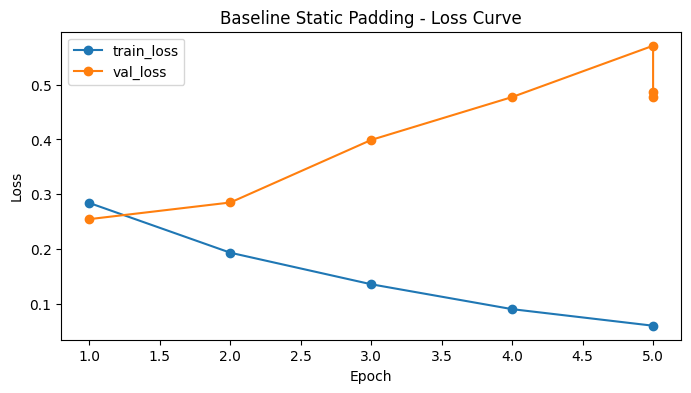

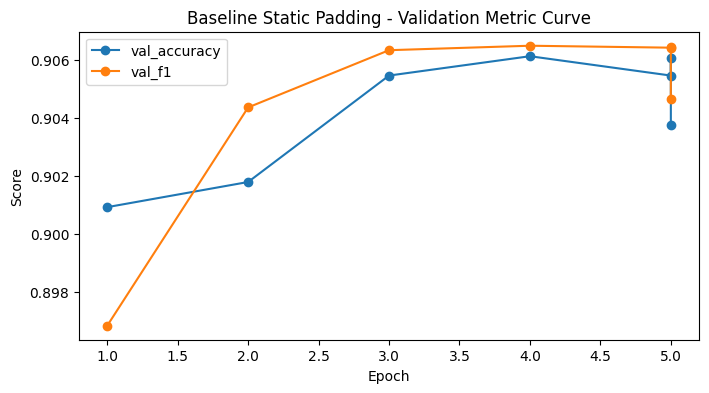

In [47]:
# ============================================================
# [STEP 5 - CELL 3] baseline 러닝커브 시각화
# ============================================================

plot_learning_curves(baseline_log_df, title_prefix="Baseline Static Padding")

In [48]:
# ============================================================
# [STEP 5 - CELL 4] test 예측 샘플 확인
# - 실제 라벨 / 예측 라벨 비교
# ============================================================

show_prediction_samples(
    trainer=trainer_baseline,
    dataset=baseline_dataset["test"],
    text_column=TEXT_COLUMN,
    label_column=LABEL_COLUMN,
    sample_count=10,
)

[sample 0]
text       : 굳 ㅋ
label      : 1
prediction : 1
--------------------------------------------------------------------------------
[sample 1]
text       : GDNTOPCLASSINTHECLUB
label      : 0
prediction : 1
--------------------------------------------------------------------------------
[sample 2]
text       : 뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아
label      : 0
prediction : 0
--------------------------------------------------------------------------------
[sample 3]
text       : 지루하지는 않은데 완전 막장임... 돈주고 보기에는....
label      : 0
prediction : 0
--------------------------------------------------------------------------------
[sample 4]
text       : 3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??
label      : 0
prediction : 0
--------------------------------------------------------------------------------
[sample 5]
text       : 음악이 주가 된, 최고의 음악영화
label      : 1
prediction : 1
--------------------------------------------------------------------------------
[sample 6]
text       : 

### STEP 6. Bucketing 적용(dynamic padding + group_by_length)

In [50]:
# ============================================================
# [STEP 6 - CELL 1] dynamic padding 전처리
# - padding=False
# - 실제 배치 시점에 DataCollatorWithPadding이 패딩 수행
# ============================================================

bucket_preprocess_function = build_preprocess_function(
    tokenizer=huggingface_tokenizer,
    text_column=TEXT_COLUMN,
    max_length=None,
    use_static_padding=False,
)

bucket_dataset = nsmc_dataset.map(
    bucket_preprocess_function,
    batched=True,
)

print(bucket_dataset)
print(bucket_dataset["train"][0].keys())

Map:   0%|          | 0/134995 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/49997 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 134995
    })
    validation: Dataset({
        features: ['id', 'document', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['id', 'document', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49997
    })
})
dict_keys(['id', 'document', 'label', 'input_ids', 'token_type_ids', 'attention_mask'])


In [51]:
# ============================================================
# [STEP 6 - CELL 2] dynamic padding용 data collator 생성
# ============================================================

data_collator_bucket = DataCollatorWithPadding(
    tokenizer=huggingface_tokenizer,
    padding="longest",
)

In [52]:
# ============================================================
# [STEP 6 - CELL 3] bucketing 학습 인자 생성
# - group_by_length=True
# ============================================================

training_arguments_bucket = make_training_arguments(
    output_dir="nsmc_klue_bert_base_bucket",
    learning_rate=2e-5,
    train_batch_size=16,
    eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    group_by_length=True, # bucketing 
)

print(training_arguments_bucket)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [61]:
# ============================================================
# [STEP 6 - CELL 4] bucketing Trainer 생성
# ============================================================

trainer_bucket = build_trainer(
    model_name=MODEL_NAME,
    training_arguments=training_arguments_bucket,
    train_dataset=bucket_dataset["train"],
    eval_dataset=bucket_dataset["validation"],
#    tokenizer=huggingface_tokenizer,
    data_collator=data_collator_bucket,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

In [63]:
# ============================================================
# [STEP 6 - CELL 5] bucketing 학습 시작
# ============================================================

bucket_train_output = trainer_bucket.train()
print("bucket train done")
print(bucket_train_output)

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.283503,0.255683,0.898667,0.895259
2,0.194242,0.297039,0.898267,0.902217
3,0.136377,0.400390,0.904200,0.904853
4,0.090633,0.472613,0.905267,0.905863
5,0.060127,0.570688,0.904000,0.904850


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

bucket train done
TrainOutput(global_step=42190, training_loss=0.1529765127054971, metrics={'train_runtime': 2218.1421, 'train_samples_per_second': 304.297, 'train_steps_per_second': 19.02, 'total_flos': 2.188493625164736e+16, 'train_loss': 0.1529765127054971, 'epoch': 5.0})


In [70]:
# ============================================================
# [STEP 6 - CELL 6] bucketing validation / test 평가
# ============================================================

bucket_val_result = trainer_bucket.evaluate(bucket_dataset["validation"])
bucket_test_result = trainer_bucket.evaluate(bucket_dataset["test"])

print("[bucket val result]")
print(bucket_val_result)

print("\n[bucket test result]")
print(bucket_test_result)

[bucket val result]
{'eval_loss': 0.4736136794090271, 'eval_accuracy': 0.9052666666666667, 'eval_f1': 0.9058753394714182, 'eval_runtime': 13.8821, 'eval_samples_per_second': 1080.526, 'eval_steps_per_second': 67.569, 'epoch': 5.0}

[bucket test result]
{'eval_loss': 0.4757644534111023, 'eval_accuracy': 0.9035142108526512, 'eval_f1': 0.9048032521608714, 'eval_runtime': 54.0678, 'eval_samples_per_second': 924.709, 'eval_steps_per_second': 57.798, 'epoch': 5.0}


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.283503,0.516928,1.600047e-05,1.0,8438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,8438,0.255683,0.898667,0.895259,13.8457,1083.369,67.747,NaN,NaN,NaN,NaN,NaN
2,0.194242,0.548337,1.200047e-05,2.0,16876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,16876,0.297039,0.898267,0.902217,13.7983,1087.090,67.979,NaN,NaN,NaN,NaN,NaN
4,0.136377,142.740189,8.000474e-06,3.0,25314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,25314,0.400390,0.904200,0.904853,13.7703,1089.301,68.118,NaN,NaN,NaN,NaN,NaN
6,0.090633,0.043246,4.000474e-06,4.0,33752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,33752,0.472613,0.905267,0.905863,13.7998,1086.971,67.972,NaN,NaN,NaN,NaN,NaN
8,0.060127,0.586298,4.740460e-10,5.0,42190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,5.0,42190,0.570688,0.904000,0.904850,13.7394,1091.753,68.271,NaN,NaN,NaN,NaN,NaN


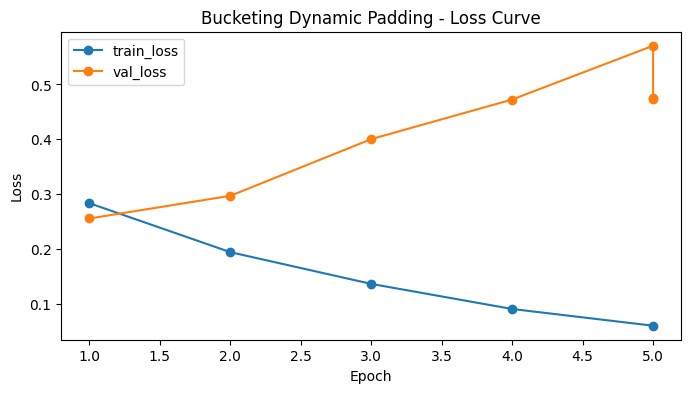

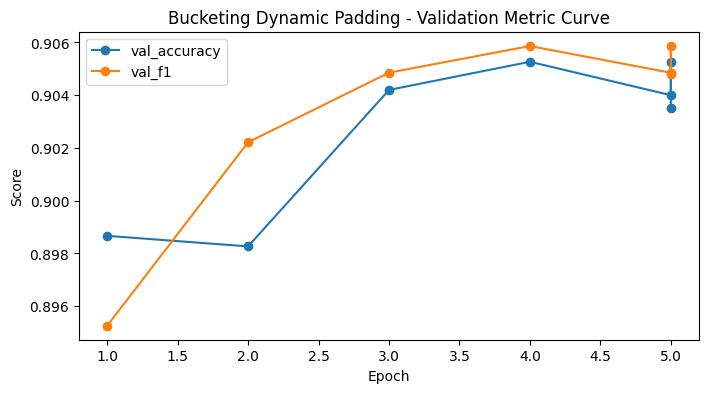

In [71]:
# ============================================================
# [STEP 6 - CELL 7] bucketing 러닝커브
# ============================================================

bucket_log_df = extract_log_history_df(trainer_bucket)
display(bucket_log_df.tail(20))

plot_learning_curves(bucket_log_df, title_prefix="Bucketing Dynamic Padding")

### STEP 7. baseline vs bucketing 비교

In [73]:
# ============================================================
# [STEP 7 - CELL 1] 결과 비교 테이블
# - accuracy
# - f1
# - runtime
# ============================================================

comparison_df = pd.DataFrame([
    {
        "experiment": "baseline_static_padding",
        "val_accuracy": baseline_val_result.get("eval_accuracy"),
        "val_f1": baseline_val_result.get("eval_f1"),
        "test_accuracy": baseline_test_result.get("eval_accuracy"),
        "test_f1": baseline_test_result.get("eval_f1"),
        "train_runtime": baseline_train_output.metrics.get("train_runtime"),
        "train_samples_per_second": baseline_train_output.metrics.get("train_samples_per_second"),
        "train_steps_per_second": baseline_train_output.metrics.get("train_steps_per_second"),
    },
    {
        "experiment": "bucket_dynamic_padding",
        "val_accuracy": bucket_val_result.get("eval_accuracy"),
        "val_f1": bucket_val_result.get("eval_f1"),
        "test_accuracy": bucket_test_result.get("eval_accuracy"),
        "test_f1": bucket_test_result.get("eval_f1"),
        "train_runtime": bucket_train_output.metrics.get("train_runtime"),
        "train_samples_per_second": bucket_train_output.metrics.get("train_samples_per_second"),
        "train_steps_per_second": bucket_train_output.metrics.get("train_steps_per_second"),
    },
])

comparison_df

,experiment,val_accuracy,val_f1,test_accuracy,test_f1,train_runtime,train_samples_per_second,train_steps_per_second
0,baseline_static_padding,0.906067,0.906435,0.903754,0.904645,3735.9490,180.670,11.293
1,bucket_dynamic_padding,0.905267,0.905875,0.903514,0.904803,2218.1421,304.297,19.020


In [74]:
# ============================================================
# [STEP 7 - CELL 2] 최고 성능 / 효율 비교 해석용 출력
# ============================================================

best_test_row = comparison_df.loc[comparison_df["test_accuracy"].idxmax()]
fastest_row = comparison_df.loc[comparison_df["train_runtime"].idxmin()]

print("[최고 test accuracy 실험]")
print(best_test_row)

print("\n[가장 빠른 학습 실험]")
print(fastest_row)

[최고 test accuracy 실험]
experiment                  baseline_static_padding
val_accuracy                               0.906067
val_f1                                     0.906435
test_accuracy                              0.903754
test_f1                                    0.904645
train_runtime                              3735.949
train_samples_per_second                     180.67
train_steps_per_second                       11.293
Name: 0, dtype: object

[가장 빠른 학습 실험]
experiment                  bucket_dynamic_padding
val_accuracy                              0.905267
val_f1                                    0.905875
test_accuracy                             0.903514
test_f1                                   0.904803
train_runtime                            2218.1421
train_samples_per_second                   304.297
train_steps_per_second                       19.02
Name: 1, dtype: object


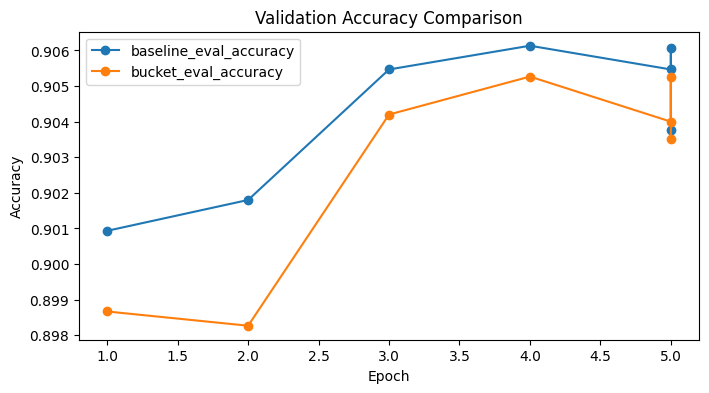

In [75]:
# ============================================================
# [STEP 7 - CELL 3] 두 러닝커브를 한 그림에서 비교
# ============================================================

plt.figure(figsize=(8, 4))

baseline_eval_curve = baseline_log_df[baseline_log_df["eval_accuracy"].notna()].copy()
bucket_eval_curve = bucket_log_df[bucket_log_df["eval_accuracy"].notna()].copy()

plt.plot(
    baseline_eval_curve["epoch"],
    baseline_eval_curve["eval_accuracy"],
    marker="o",
    label="baseline_eval_accuracy",
)

plt.plot(
    bucket_eval_curve["epoch"],
    bucket_eval_curve["eval_accuracy"],
    marker="o",
    label="bucket_eval_accuracy",
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()